In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, 
                             classification_report, confusion_matrix)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


--- INICIANDO ENTRENAMIENTO ---
Se probará LinearSVC y un SVM (RBF) con parámetros reducidos.



Progreso Global: 100%|██████████| 4/4 [1:26:14<00:00, 1293.63s/modelo, current_model=SVM (RBF Kernel)]




🏆 EL GANADOR ES: SVM (RBF Kernel)

--- REPORTE DE CLASIFICACIÓN (TEST) ---
              precision    recall  f1-score   support

           0       0.90      0.80      0.85      7918
           1       0.52      0.71      0.60      2431

    accuracy                           0.78     10349
   macro avg       0.71      0.75      0.72     10349
weighted avg       0.81      0.78      0.79     10349



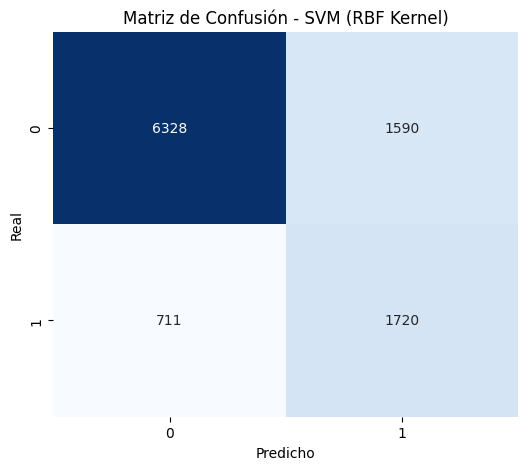

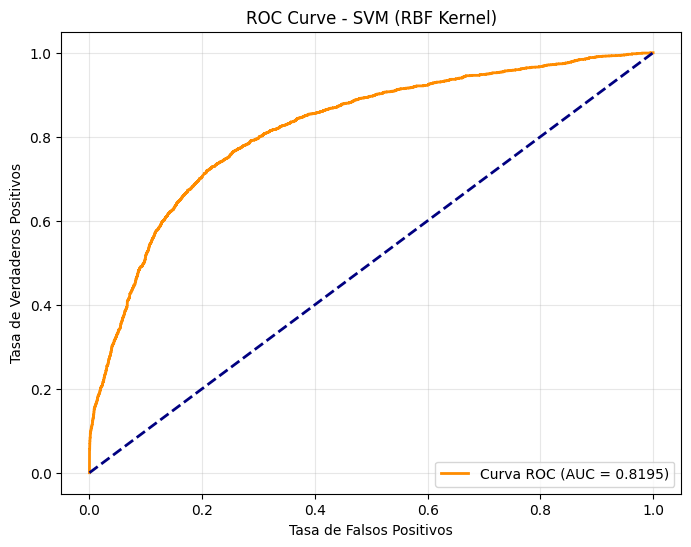


--- RESUMEN FINAL DE COMPARATIVA ---
             Modelo  AUC Train  AUC Test  Diff AUC  Accuracy  F1-Score  Recall  Precision
   SVM (RBF Kernel)     0.8692    0.8195    0.0497    0.7777    0.5992  0.7075     0.5196
         Linear SVC     0.7832    0.7722    0.0110    0.6752    0.5179  0.7425     0.3976
Logistic Regression     0.7836    0.7722    0.0114    0.6842    0.5224  0.7351     0.4051
        Naive Bayes     0.7384    0.7261    0.0123    0.6204    0.4804  0.7470     0.3541


In [5]:

if __name__ == "__main__":
    
    # 1. CARGA Y PREPROCESAMIENTO RÁPIDO

    df = pd.read_csv('Datos/Transformados/df_meteorologico.csv')

    drop_cols = [
        'Unnamed: 0', 'status', 'cancelled_at', 'cancellation_reason', 
        'cancellation_lead_time', 'days_before_cancel', 'days_before_checkin', 
        'completed_entry_forms_count', 'all_entry_forms_completed', 
        'last_entry_form_completed_at', 'checkout_time', 'checkin_time', 'booked_at',
        'travel_agency_name', 'requested_category_name', 'requested_category', 'asset',
        'asset_opening_date', 'idema_code', 'F_C_I', 'F_C_O', 'IDEMA'
    ]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

    numeric_features = [
        'lead_time', 'lenght_of_stay', 'adult_count', 'total_adr', 
        'IQR_hrMedia', 'IQR_tmed', 'product_count'
    ]
    categorical_features = ['origin', 'asset_type', 'rate_type', 'business_segment', 'recurrence']

    for col in categorical_features:
        df[col] = df[col].fillna('Unknown').astype(str)
    df[numeric_features] = df[numeric_features].fillna(df[numeric_features].median())

    X = df[numeric_features + categorical_features]
    y = df['is_cancelled']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

    # 2. CONFIGURACIÓN DE MODELOS

    models_config = {
        # MODELO 1: NAIVE BAYES
        "Naive Bayes": {
            "model": GaussianNB(),
            "params": {'classifier__var_smoothing': np.logspace(-9, -2, 3)}
        },
        
        # MODELO 2: REGRESIÓN LOGÍSTICA
        "Logistic Regression": {
            "model": LogisticRegression(max_iter=1000, random_state=42),
            "params": {'classifier__C': [1, 10], 'classifier__solver': ['liblinear']}
        },

        # MODELO 3: LINEAR SVC
        "Linear SVC": {
            "model": CalibratedClassifierCV(LinearSVC(dual=False, random_state=42)),
            "params": {
                'classifier__estimator__C': [0.1, 1, 10] 
            }
        },

        # MODELO 4: SVM RBF
        "SVM (RBF Kernel)": {
            "model": SVC(probability=True, random_state=42, cache_size=500),
            "params": {
                'classifier__C': [1, 10],  
                'classifier__gamma': ['scale'], 
                'classifier__kernel': ['rbf'] 
            }
        }
    }

    # 3. EJECUCIÓN DEL GRID SEARCH

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    results = []
    best_model_obj = None
    best_auc = 0
    best_model_name = ""

    print("\n--- INICIANDO ENTRENAMIENTO ---")
    print("Se probará LinearSVC y un SVM (RBF) con parámetros reducidos.\n")

    iterator = tqdm(models_config.items(), desc="Progreso Global", unit="modelo")

    for name, config in iterator:
        iterator.set_postfix(current_model=name)
        
        pipeline = ImbPipeline(steps=[
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=42)),
            ('classifier', config['model'])
        ])
        
        grid = GridSearchCV(pipeline, config['params'], cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0) # verbose a 0 para limpieza
        grid.fit(X_train, y_train)
        
        # --- AQUÍ EMPIEZAN LOS CAMBIOS DE MÉTRICAS ---
        
        # 1. Obtenemos el mejor estimador
        current_best_model = grid.best_estimator_
        
        # 2. Obtenemos probabilidades para Train (ver overfitting) y Test (validación)
        y_train_prob = current_best_model.predict_proba(X_train)[:, 1]
        y_test_prob = current_best_model.predict_proba(X_test)[:, 1]
        y_test_pred = current_best_model.predict(X_test)
        
        # 3. Calculamos métricas detalladas
        auc_train = roc_auc_score(y_train, y_train_prob)
        auc_test = roc_auc_score(y_test, y_test_prob)
        acc_test = accuracy_score(y_test, y_test_pred)
        prec_test = precision_score(y_test, y_test_pred)
        rec_test = recall_score(y_test, y_test_pred)
        f1_test = f1_score(y_test, y_test_pred)

        # 4. Guardamos en el diccionario expandido
        results.append({
            "Modelo": name,
            "AUC Train": auc_train,
            "AUC Test": auc_test,
            "Diff AUC": auc_train - auc_test, # Overfitting metric
            "Accuracy": acc_test,
            "Precision": prec_test,
            "Recall": rec_test,
            "F1-Score": f1_test,
            "Mejores Parámetros": grid.best_params_
        })
        
        # Lógica del ganador (usamos AUC Test como criterio final si prefieres, o Train CV)
        if auc_test > best_auc:
            best_auc = auc_test
            best_model_obj = current_best_model
            best_model_name = name

    # 4. RESULTADOS Y GRÁFICAS

    print(f"\n\n🏆 EL GANADOR ES: {best_model_name}")
    
    y_prob = best_model_obj.predict_proba(X_test)[:, 1]
    y_pred = best_model_obj.predict(X_test)

    print("\n--- REPORTE DE CLASIFICACIÓN (TEST) ---")
    print(classification_report(y_test, y_pred))

    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Matriz de Confusión - {best_model_name}')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    test_auc = roc_auc_score(y_test, y_prob)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {test_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title(f'ROC Curve - {best_model_name}')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    
    print("\n--- RESUMEN FINAL DE COMPARATIVA ---")
    df_results = pd.DataFrame(results)
    # Ordenamos por AUC Test y mostramos las nuevas columnas
    df_results = df_results.sort_values(by="AUC Test", ascending=False)
    cols_to_show = ["Modelo", "AUC Train", "AUC Test", "Diff AUC", "Accuracy", "F1-Score", "Recall", "Precision"]
    print(df_results[cols_to_show].round(4).to_string(index=False))
